Praca z danymi i GitHub

Instrukcje:
Przprowadz analizy danych na podstawie pliku z załącznika, zwróć uwagę na typ załączonego pliku - czym go otworzysz (zwróć uwagę, że plik ma wiele zakładek)?

projekt_data_science_szablon.md

W moich danych mam listę zakupów danego dnia w danej kategorii podzieloną na płeć konsumenta, ilość kupionego towaru, jego cenę oraz całkowity koszt rachunku

Chciałbym się dowiedzieć, czy w kolejnych miesiącach więcej na zakupy wydadzą mężczyźni czy kobiety. Wydaje mi się, że poprawną odpowiedzią będą kobiety, które wydadzą pieniądze głównie na produkty 'Beauty' i 'Clothing'.

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix


## 1. Import i wczytanie danych

In [63]:
df_csv = pd.read_csv('SalesDataset.csv')
df = df_csv.copy().drop(columns=['Unnamed: 0'])
df.head()

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,2023-11-24,Male,34,Beauty,3,50,150
1,2023-02-27,Female,26,Clothing,2,500,1000
2,2023-01-13,Male,50,Electronics,1,30,30
3,2023-05-21,Male,37,Clothing,1,500,500
4,2023-05-06,Male,30,Beauty,2,50,100


## 2. Pierwsze spojrzenie na dane

In [64]:
# Kształt danych (liczba wierszy i kolumn)
print(df.shape)
# Informacje o typach danych i brakach
df.info()
# Statystyki opisowe
df.describe(include="all")
# Liczba braków w każdej kolumnie
df.isna().sum()

(1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              1000 non-null   object
 1   Gender            1000 non-null   object
 2   Age               1000 non-null   int64 
 3   Product Category  1000 non-null   object
 4   Quantity          1000 non-null   int64 
 5   Price per Unit    1000 non-null   int64 
 6   Total Amount      1000 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 54.8+ KB


Date                0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Komentarz:

Mam 1000 obserwacji (wierszy) i 8 cech (z tego jedna to index, więc praktycznie mam 7)

Ważne cechy to: płeć, kategoria produktu, całkowita kwota

Brak braków danych, dobrą docelową zmienną będzie 'Total Amount'

## 3. EDA: rozkłady, outliery, korelacje

Index(['Age', 'Quantity', 'Price per Unit', 'Total Amount'], dtype='object')


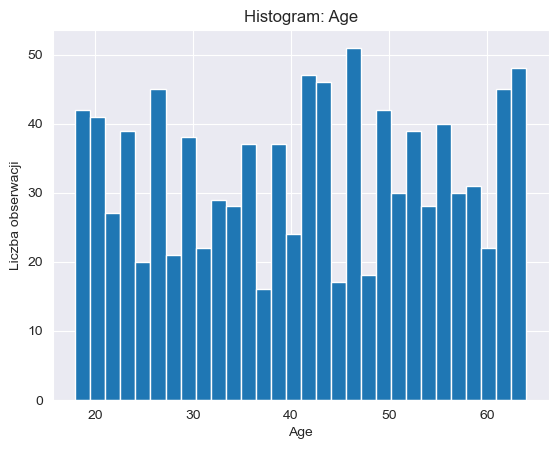

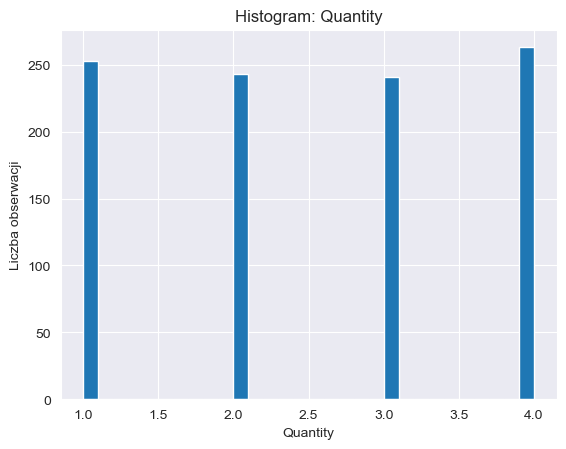

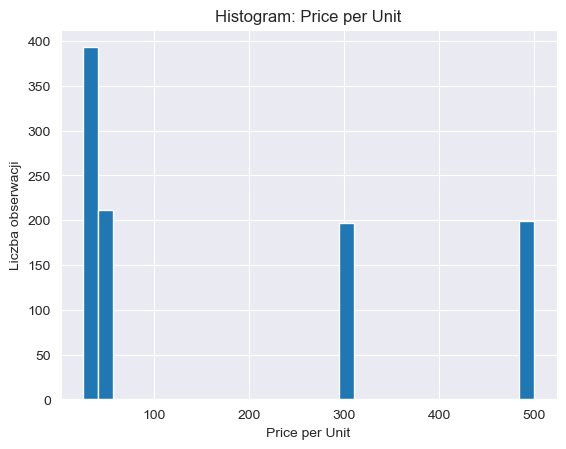

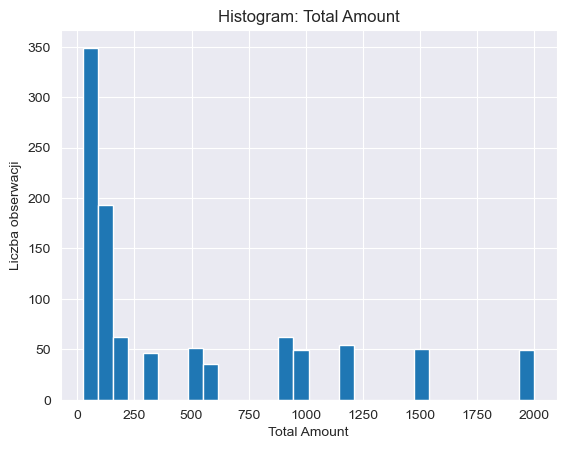

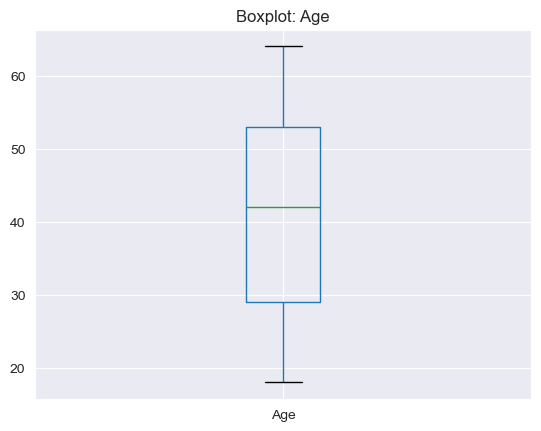

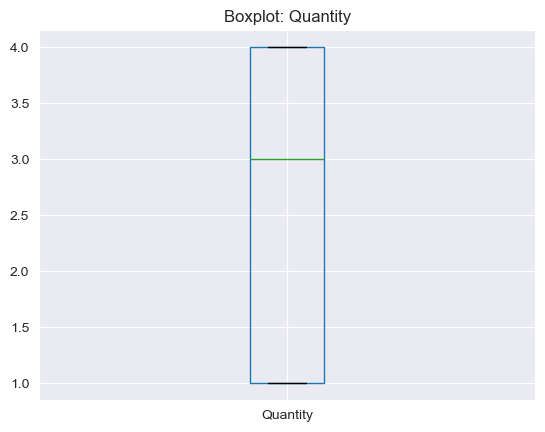

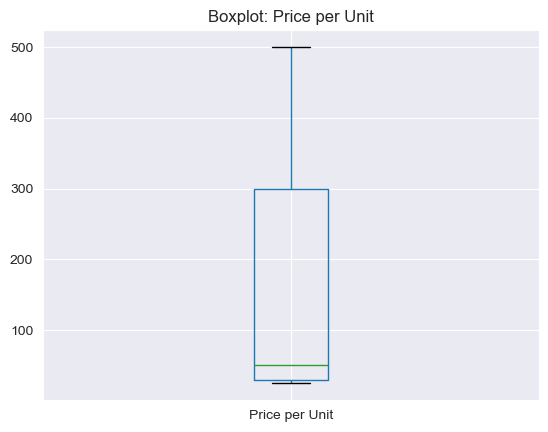

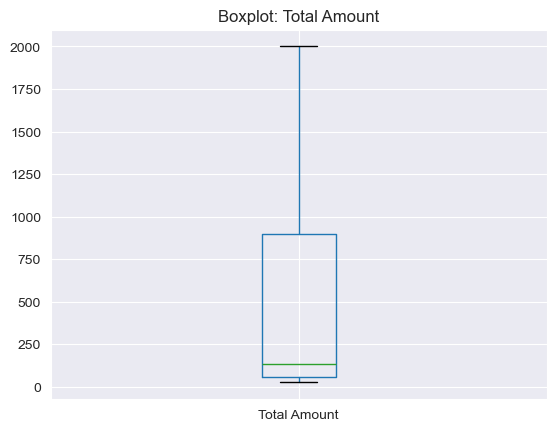

                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


In [65]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(numeric_cols)

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczba obserwacji")
    plt.show()

for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.show()

corr = df.corr(numeric_only=True)
print(corr)

Zauważone zależności i problemy:

Ludzie w każdym wieku wykonali średnio po 30 zakupów.
Ilość zakupionego towaru jest zawsze liczbą całkowitą.
Najwięcej dokonano zakupu pojedynczego towaru w cenie do 100.
Dokonano około 50 zakupów o całkowitej cenie 500, 1000, 1500, 2000.

## 4. Preprocesing danych

In [66]:
data = df.copy()

# jako, że w bazie nie mam miejsc pustych nie używam kodu:
# # Przykład: imputacja medianą dla kolumn numerycznych
# for col in numeric_cols:
#     if data[col].isna().sum() > 0:
#         data[col] = data[col].fillna(data[col].median())
#
# # Przykład: wypełnianie braków w kolumnach kategorycznych
# cat_cols = data.select_dtypes(include=["object", "category"]).columns
#
# for col in cat_cols:
#     if data[col].isna().sum() > 0:
#         data[col] = data[col].fillna("brak_danych")

In [67]:
data_encoded = pd.get_dummies(data, drop_first=True)
data_encoded.head()

,Age,Quantity,Price per Unit,Total Amount,Date_2023-01-02,Date_2023-01-03,Date_2023-01-04,Date_2023-01-05,Date_2023-01-06,Date_2023-01-07,...,Date_2023-12-25,Date_2023-12-26,Date_2023-12-27,Date_2023-12-28,Date_2023-12-29,Date_2023-12-31,Date_2024-01-01,Gender_Male,Product Category_Clothing,Product Category_Electronics
0,34,3,50,150,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,26,2,500,1000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,50,1,30,30,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,37,1,500,500,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
4,30,2,50,100,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


Wybrano zmienną docelową 'Total Amount' - całkowita kwota transakcji, można modelować:

prognozę wartości transakcji, analizę co wpływa na wielkość wydatków.

In [68]:
target_col = "Total Amount"

X = data_encoded.drop(target_col, axis=1)
y = data_encoded[target_col]

print(X.shape, y.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(1000, 350) (1000,)


## 5. Model ML - regresja lub klasyfikacja

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 350), (200, 350), (800,), (200,))

### 5.1. Model regresyjny (opcjonalnie)

In [73]:
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred_reg = reg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_reg)
mae = mean_absolute_error(y_test, y_pred_reg)

print(mse, mae)

71222.79454610063 212.53727720177895


### 5.2. Model klasyfikacyjny (opcjonalnie)

In [74]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred_clf = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred_clf)
cm = confusion_matrix(y_test, y_pred_clf)

print(acc, cm)

0.22 [[1 0 1 1 0 3 1 0 0 0 2 0 1 0 0 0 0 0]
 [1 1 4 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 8 3 0 1 1 0 1 0 1 0 0 0 0 0 0 0]
 [0 0 5 0 0 1 2 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 1 0 2 1 0 0 1 0 0 1 0 0]
 [0 0 3 1 0 1 2 0 0 1 0 0 0 0 0 1 0 0]
 [0 1 6 3 1 3 2 0 4 2 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 2 0 1 1 3 0 0 0 0 0 0 0 0]
 [0 0 2 1 1 0 2 1 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 2 3 4 2 2 0 0 0 2 0 2 0 0]
 [1 1 4 3 0 0 0 0 0 0 1 4 0 0 0 0 1 0]
 [0 1 1 0 0 0 0 0 0 0 0 4 0 0 2 0 0 0]
 [0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0]
 [0 0 0 0 1 0 2 1 0 0 0 1 0 5 2 1 0 1]
 [0 1 0 0 0 0 0 0 0 0 1 2 0 0 7 0 1 0]
 [0 0 0 0 0 0 0 0 0 2 0 0 0 4 0 1 2 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 5 1 0 2 3]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 6]]


## 6. Podsumowanie i wnioski

asdsa

In [72]:
# Napisz krótkie podsumowanie projektu, odpowiadając na pytania:
# - czego dowiedziałeś/dowiedziałaś się o danych,
# - jakie decyzje preprocessingowe podjąłeś/podjęłaś,
# - jak poradził sobie model,
# - co można by zrobić dalej.